# BTC/USDT — Fear & Greed Index DCA Backtest (v2)

## Strategy Logic

### 1. Monthly Regime Evaluation (1st trading day of each month)
Check F&G → set the month's total DCA budget → split into equal daily amounts.

| F&G on Month Start | Sentiment | Monthly Budget (% of cash) |
|--------------------|-----------|----------------------------|
| 0 – 25 | Extreme Fear | 20% of cash |
| 26 – 45 | Fear | 12% of cash |
| 46 – 55 | Mild Fear | 6% of cash |
| > 55 | Neutral / Greed | 0% — no DCA this month |

Daily DCA amount = `monthly_budget ÷ days_in_month`

### 2. Hard Buy Trigger (daily check, crossover)
When F&G **crosses below 40** → immediate one-shot buy of **10% of available cash**.  
Resets when F&G rises back above 40 (allowing another trigger on the next descent).

### 3. Hard Sell Trigger (daily check, crossover)
When F&G **crosses above 80** → immediate sell of **25% of BTC holdings** + **stop DCA**.  
DCA restarts only at the next month's evaluation.  
Resets when F&G drops back below 80.

**Metrics:** Sharpe Ratio · Sortino Ratio · Maximum Drawdown · CAGR

In [14]:
# pip install yfinance requests pandas numpy matplotlib seaborn
import calendar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import yfinance as yf
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
print('Libraries loaded.')

Libraries loaded.


In [15]:
def fetch_btc_price(start='2018-02-01', end=None):
    if end is None:
        end = datetime.today().strftime('%Y-%m-%d')
    ticker = yf.Ticker('BTC-USD')
    raw = ticker.history(start=start, end=end, interval='1d')
    raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']].reset_index()
    raw.rename(columns={
        'Date': 'date', 'Open': 'open', 'High': 'high',
        'Low': 'low', 'Close': 'close', 'Volume': 'volume'
    }, inplace=True)
    raw['date'] = raw['date'].dt.tz_localize(None).dt.normalize()
    return raw.sort_values('date').reset_index(drop=True)

btc = fetch_btc_price(start='2018-02-01')
print(f'BTC/USD daily data: {len(btc)} rows  |  {btc.date.min().date()} → {btc.date.max().date()}')
btc.tail(3)

BTC/USD daily data: 3010 rows  |  2018-02-01 → 2026-04-29


,date,open,high,low,close,volume
3007,2026-04-27,78661.015625,79488.171875,76481.343750,77366.625000,38135631927
3008,2026-04-28,77368.117188,77483.867188,75673.601562,76350.671875,32056900880
3009,2026-04-29,76350.687500,77884.968750,74958.570312,75776.132812,41460907886


In [16]:
def fetch_fear_greed(limit=3000):
    url = f'https://api.alternative.me/fng/?limit={limit}&format=json'
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    records = resp.json()['data']
    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['timestamp'].astype(int), unit='s').dt.normalize()
    df['fg_value'] = df['value'].astype(int)
    df['fg_class'] = df['value_classification']
    return df[['date', 'fg_value', 'fg_class']].sort_values('date').reset_index(drop=True)

fg = fetch_fear_greed(limit=3000)
print(f'Fear & Greed Index: {len(fg)} rows  |  {fg.date.min().date()} → {fg.date.max().date()}')
fg.tail(3)

Fear & Greed Index: 3000 rows  |  2018-02-08 → 2026-04-30


,date,fg_value,fg_class
2997,2026-04-28,33,Fear
2998,2026-04-29,26,Fear
2999,2026-04-30,29,Fear


In [17]:
data = pd.merge(btc, fg, on='date', how='inner').sort_values('date').reset_index(drop=True)
print(f'Combined dataset: {len(data)} trading days  |  {data.date.min().date()} → {data.date.max().date()}')
data[['date', 'close', 'fg_value', 'fg_class']].tail(5)

Combined dataset: 2999 trading days  |  2018-02-08 → 2026-04-29


,date,close,fg_value,fg_class
2994,2026-04-25,77612.015625,31,Fear
2995,2026-04-26,78657.539062,33,Fear
2996,2026-04-27,77366.625000,47,Neutral
2997,2026-04-28,76350.671875,33,Fear
2998,2026-04-29,75776.132812,26,Fear


In [18]:
PARAMS = {
    'initial_capital': 10_000,    # Starting USDT
    'fee_rate': 0.001,            # 0.1% per trade (Binance taker)
    'min_trade_usdt': 10,         # Minimum order size

    # Monthly evaluation: checked on first trading day of each new month.
    # Determines the total DCA budget for that month.
    # daily_dca = monthly_budget / days_in_month
    # (max_fg_inclusive, pct_of_available_cash_as_monthly_budget)
    'monthly_tiers': [
        (25,  0.20),   # Extreme Fear  → 20% of cash across the month
        (45,  0.12),   # Fear          → 12% of cash
        (55,  0.06),   # Mild Fear     →  6% of cash
        # F&G > 55 at month start → no DCA program launched this month
    ],

    # Hard buy trigger: crossover — fires ONCE when F&G drops below this level.
    # Resets when F&G rises back above it (allowing re-trigger on next descent).
    'buy_trigger': 40,
    'buy_trigger_pct': 0.10,      # Deploy 10% of available cash immediately

    # Hard sell trigger: crossover — fires ONCE when F&G crosses above this level.
    # Sells a chunk of BTC and stops the current DCA program.
    # Resets when F&G drops back below it.
    'sell_trigger': 80,
    'sell_trigger_pct': 0.25,     # Sell 25% of BTC holdings immediately
}
print('Parameters set.')

Parameters set.


In [19]:
def get_monthly_budget_pct(fg_value, monthly_tiers):
    for threshold, pct in sorted(monthly_tiers, key=lambda t: t[0]):
        if fg_value <= threshold:
            return pct
    return 0.0

# Preview monthly budget allocation across the F&G spectrum
print('F&G at month start  |  Monthly budget  |  Daily DCA (30-day month)')
print('-' * 65)
for val in [10, 20, 30, 40, 50, 55, 60, 70, 80, 90]:
    pct = get_monthly_budget_pct(val, PARAMS['monthly_tiers'])
    daily = pct / 30 * 100
    label = 'DCA active' if pct > 0 else 'No DCA'
    print(f'  F&G {val:3d}   →   {pct*100:5.1f}% of cash   →   {daily:.3f}%/day   [{label}]')

print()
print(f'Hard buy  trigger: F&G crosses below {PARAMS["buy_trigger"]}  → buy {PARAMS["buy_trigger_pct"]*100:.0f}% of cash (one-shot)')
print(f'Hard sell trigger: F&G crosses above {PARAMS["sell_trigger"]} → sell {PARAMS["sell_trigger_pct"]*100:.0f}% of BTC  (one-shot + stop DCA)')

F&G at month start  |  Monthly budget  |  Daily DCA (30-day month)
-----------------------------------------------------------------
  F&G  10   →    20.0% of cash   →   0.667%/day   [DCA active]
  F&G  20   →    20.0% of cash   →   0.667%/day   [DCA active]
  F&G  30   →    12.0% of cash   →   0.400%/day   [DCA active]
  F&G  40   →    12.0% of cash   →   0.400%/day   [DCA active]
  F&G  50   →     6.0% of cash   →   0.200%/day   [DCA active]
  F&G  55   →     6.0% of cash   →   0.200%/day   [DCA active]
  F&G  60   →     0.0% of cash   →   0.000%/day   [No DCA]
  F&G  70   →     0.0% of cash   →   0.000%/day   [No DCA]
  F&G  80   →     0.0% of cash   →   0.000%/day   [No DCA]
  F&G  90   →     0.0% of cash   →   0.000%/day   [No DCA]

Hard buy  trigger: F&G crosses below 40  → buy 10% of cash (one-shot)
Hard sell trigger: F&G crosses above 80 → sell 25% of BTC  (one-shot + stop DCA)


In [20]:
def run_backtest(data, params):
    cash = float(params['initial_capital'])
    btc_held = 0.0
    fee = params['fee_rate']
    min_trade = params['min_trade_usdt']

    buy_threshold = params['buy_trigger']
    sell_threshold = params['sell_trigger']
    buy_trigger_pct = params['buy_trigger_pct']
    sell_trigger_pct = params['sell_trigger_pct']

    dca_active = False
    dca_daily_amount = 0.0
    current_month = None

    # Crossover state trackers
    buy_armed = True     # True = ready to fire; False = already fired, waiting for reset
    sell_armed = True    # same logic for sell

    rows = []

    for _, row in data.iterrows():
        date = row['date']
        price = row['close']
        fg = row['fg_value']
        month_key = (date.year, date.month)

        action = 'HOLD'
        trade_usdt = 0.0
        trade_btc = 0.0

        # ── Monthly evaluation (first trading day of each new month) ────────
        if month_key != current_month:
            current_month = month_key
            tier_pct = get_monthly_budget_pct(fg, params['monthly_tiers'])
            if tier_pct > 0 and cash >= min_trade:
                days_in_month = calendar.monthrange(date.year, date.month)[1]
                monthly_budget = cash * tier_pct
                dca_daily_amount = monthly_budget / days_in_month
                dca_active = True
            else:
                # Month starts in neutral/greed: close out any existing DCA program
                dca_active = False
                dca_daily_amount = 0.0

        # ── SELL trigger: crossover above sell_threshold ─────────────────
        if fg >= sell_threshold:
            if sell_armed and btc_held > 0:
                btc_to_sell = btc_held * sell_trigger_pct
                gross = btc_to_sell * price
                if gross >= min_trade:
                    cash += gross * (1 - fee)
                    btc_held -= btc_to_sell
                    action = 'SELL'
                    trade_usdt = gross
                    trade_btc = btc_to_sell
            sell_armed = False        # disarm until F&G drops below threshold
            dca_active = False        # always stop DCA at extreme greed
            dca_daily_amount = 0.0
        else:
            sell_armed = True         # re-arm once F&G is back below threshold

        # ── BUY triggers (only runs if we did not sell today) ─────────────
        if action != 'SELL':

            # Hard buy crossover: F&G drops below buy_threshold
            if fg < buy_threshold:
                if buy_armed and cash >= min_trade:
                    spend = cash * buy_trigger_pct
                    if spend >= min_trade:
                        btc_bought = spend * (1 - fee) / price
                        cash -= spend
                        btc_held += btc_bought
                        action = 'BUY'
                        trade_usdt += spend
                        trade_btc += btc_bought
                buy_armed = False     # disarm until F&G rises back above threshold
            else:
                buy_armed = True      # re-arm once F&G is back above threshold

            # Daily DCA buy (runs every day while active, including on buy-trigger days)
            if dca_active and cash >= min_trade:
                spend = min(dca_daily_amount, cash)
                if spend >= min_trade:
                    btc_bought = spend * (1 - fee) / price
                    cash -= spend
                    btc_held += btc_bought
                    action = 'BUY'
                    trade_usdt += spend
                    trade_btc += btc_bought

        rows.append({
            'date':            date,
            'price':           price,
            'fg_value':        fg,
            'fg_class':        row['fg_class'],
            'cash':            cash,
            'btc_held':        btc_held,
            'btc_value':       btc_held * price,
            'portfolio_value': cash + btc_held * price,
            'action':          action,
            'trade_usdt':      trade_usdt,
            'trade_btc':       trade_btc,
        })

    return pd.DataFrame(rows)

print('Backtest engine defined.')

Backtest engine defined.


In [21]:
results = run_backtest(data, PARAMS)

action_counts = results['action'].value_counts().to_dict()
total_days = len(results)
print(f'Backtest complete: {total_days} days')
print(f'  BUY signals:  {action_counts.get("BUY",  0)}  ({action_counts.get("BUY", 0)/total_days*100:.1f}% of days)')
print(f'  SELL signals: {action_counts.get("SELL", 0)}  ({action_counts.get("SELL",0)/total_days*100:.1f}% of days)')
print(f'  HOLD days:    {action_counts.get("HOLD", 0)}  ({action_counts.get("HOLD",0)/total_days*100:.1f}% of days)')
results[['date', 'price', 'fg_value', 'fg_class', 'cash', 'btc_held', 'portfolio_value', 'action']].tail(5)

Backtest complete: 2999 days
  BUY signals:  1046  (34.9% of days)
  SELL signals: 26  (0.9% of days)
  HOLD days:    1927  (64.3% of days)


,date,price,fg_value,fg_class,cash,btc_held,portfolio_value,action
2994,2026-04-25,77612.015625,31,Fear,2203.811889,0.895336,71692.662407,BUY
2995,2026-04-26,78657.539062,33,Fear,2184.187563,0.895585,72628.737810,BUY
2996,2026-04-27,77366.625000,47,Neutral,2164.563236,0.895839,71472.594289,BUY
2997,2026-04-28,76350.671875,33,Fear,1928.482586,0.898928,70562.227894,BUY
2998,2026-04-29,75776.132812,26,Fear,1908.858259,0.899187,70045.739106,BUY


In [22]:
def compute_metrics(results, params, risk_free_rate=0.04):
    pv = results['portfolio_value']
    initial = params['initial_capital']
    final = pv.iloc[-1]
    daily_ret = pv.pct_change().dropna()

    n_years = len(results) / 365.25
    rf_daily = (1 + risk_free_rate) ** (1 / 365.25) - 1
    excess = daily_ret - rf_daily

    # Sharpe: annualised excess return / total daily vol
    sharpe = (excess.mean() / daily_ret.std()) * np.sqrt(365.25)

    # Sortino: annualised excess return / downside vol only
    downside = daily_ret[daily_ret < rf_daily]
    sortino = (excess.mean() / downside.std()) * np.sqrt(365.25) if len(downside) > 1 else np.nan

    # Maximum Drawdown
    rolling_max = pv.cummax()
    drawdown = (pv - rolling_max) / rolling_max
    max_dd = drawdown.min()

    # Longest drawdown duration (consecutive days underwater)
    in_dd = drawdown < 0
    groups = (in_dd != in_dd.shift()).cumsum()
    max_dd_days = in_dd.groupby(groups).sum().max()

    cagr = (final / initial) ** (1 / n_years) - 1
    total_ret = (final - initial) / initial
    btc_bh_ret = (results['price'].iloc[-1] - results['price'].iloc[0]) / results['price'].iloc[0]

    n_buys  = (results['action'] == 'BUY').sum()
    n_sells = (results['action'] == 'SELL').sum()

    metrics = pd.DataFrame({
        'Metric': [
            'Initial Capital', 'Final Portfolio Value',
            'Total Return', 'CAGR',
            'Sharpe Ratio', 'Sortino Ratio',
            'Max Drawdown', 'Max DD Duration (days)',
            'Buy Signals', 'Sell Signals',
            'BTC Buy & Hold Return',
        ],
        'Value': [
            f'${initial:,.0f}', f'${final:,.2f}',
            f'{total_ret:.2%}', f'{cagr:.2%}',
            f'{sharpe:.4f}', f'{sortino:.4f}',
            f'{max_dd:.2%}', int(max_dd_days),
            int(n_buys), int(n_sells),
            f'{btc_bh_ret:.2%}',
        ]
    })
    return metrics, drawdown

metrics_df, drawdown_series = compute_metrics(results, PARAMS)
metrics_df

,Metric,Value
0,Initial Capital,"$10,000"
1,Final Portfolio Value,"$70,045.74"
2,Total Return,600.46%
3,CAGR,26.75%
4,Sharpe Ratio,0.6574
5,Sortino Ratio,0.8524
6,Max Drawdown,-68.05%
7,Max DD Duration (days),827
8,Buy Signals,1046
9,Sell Signals,26


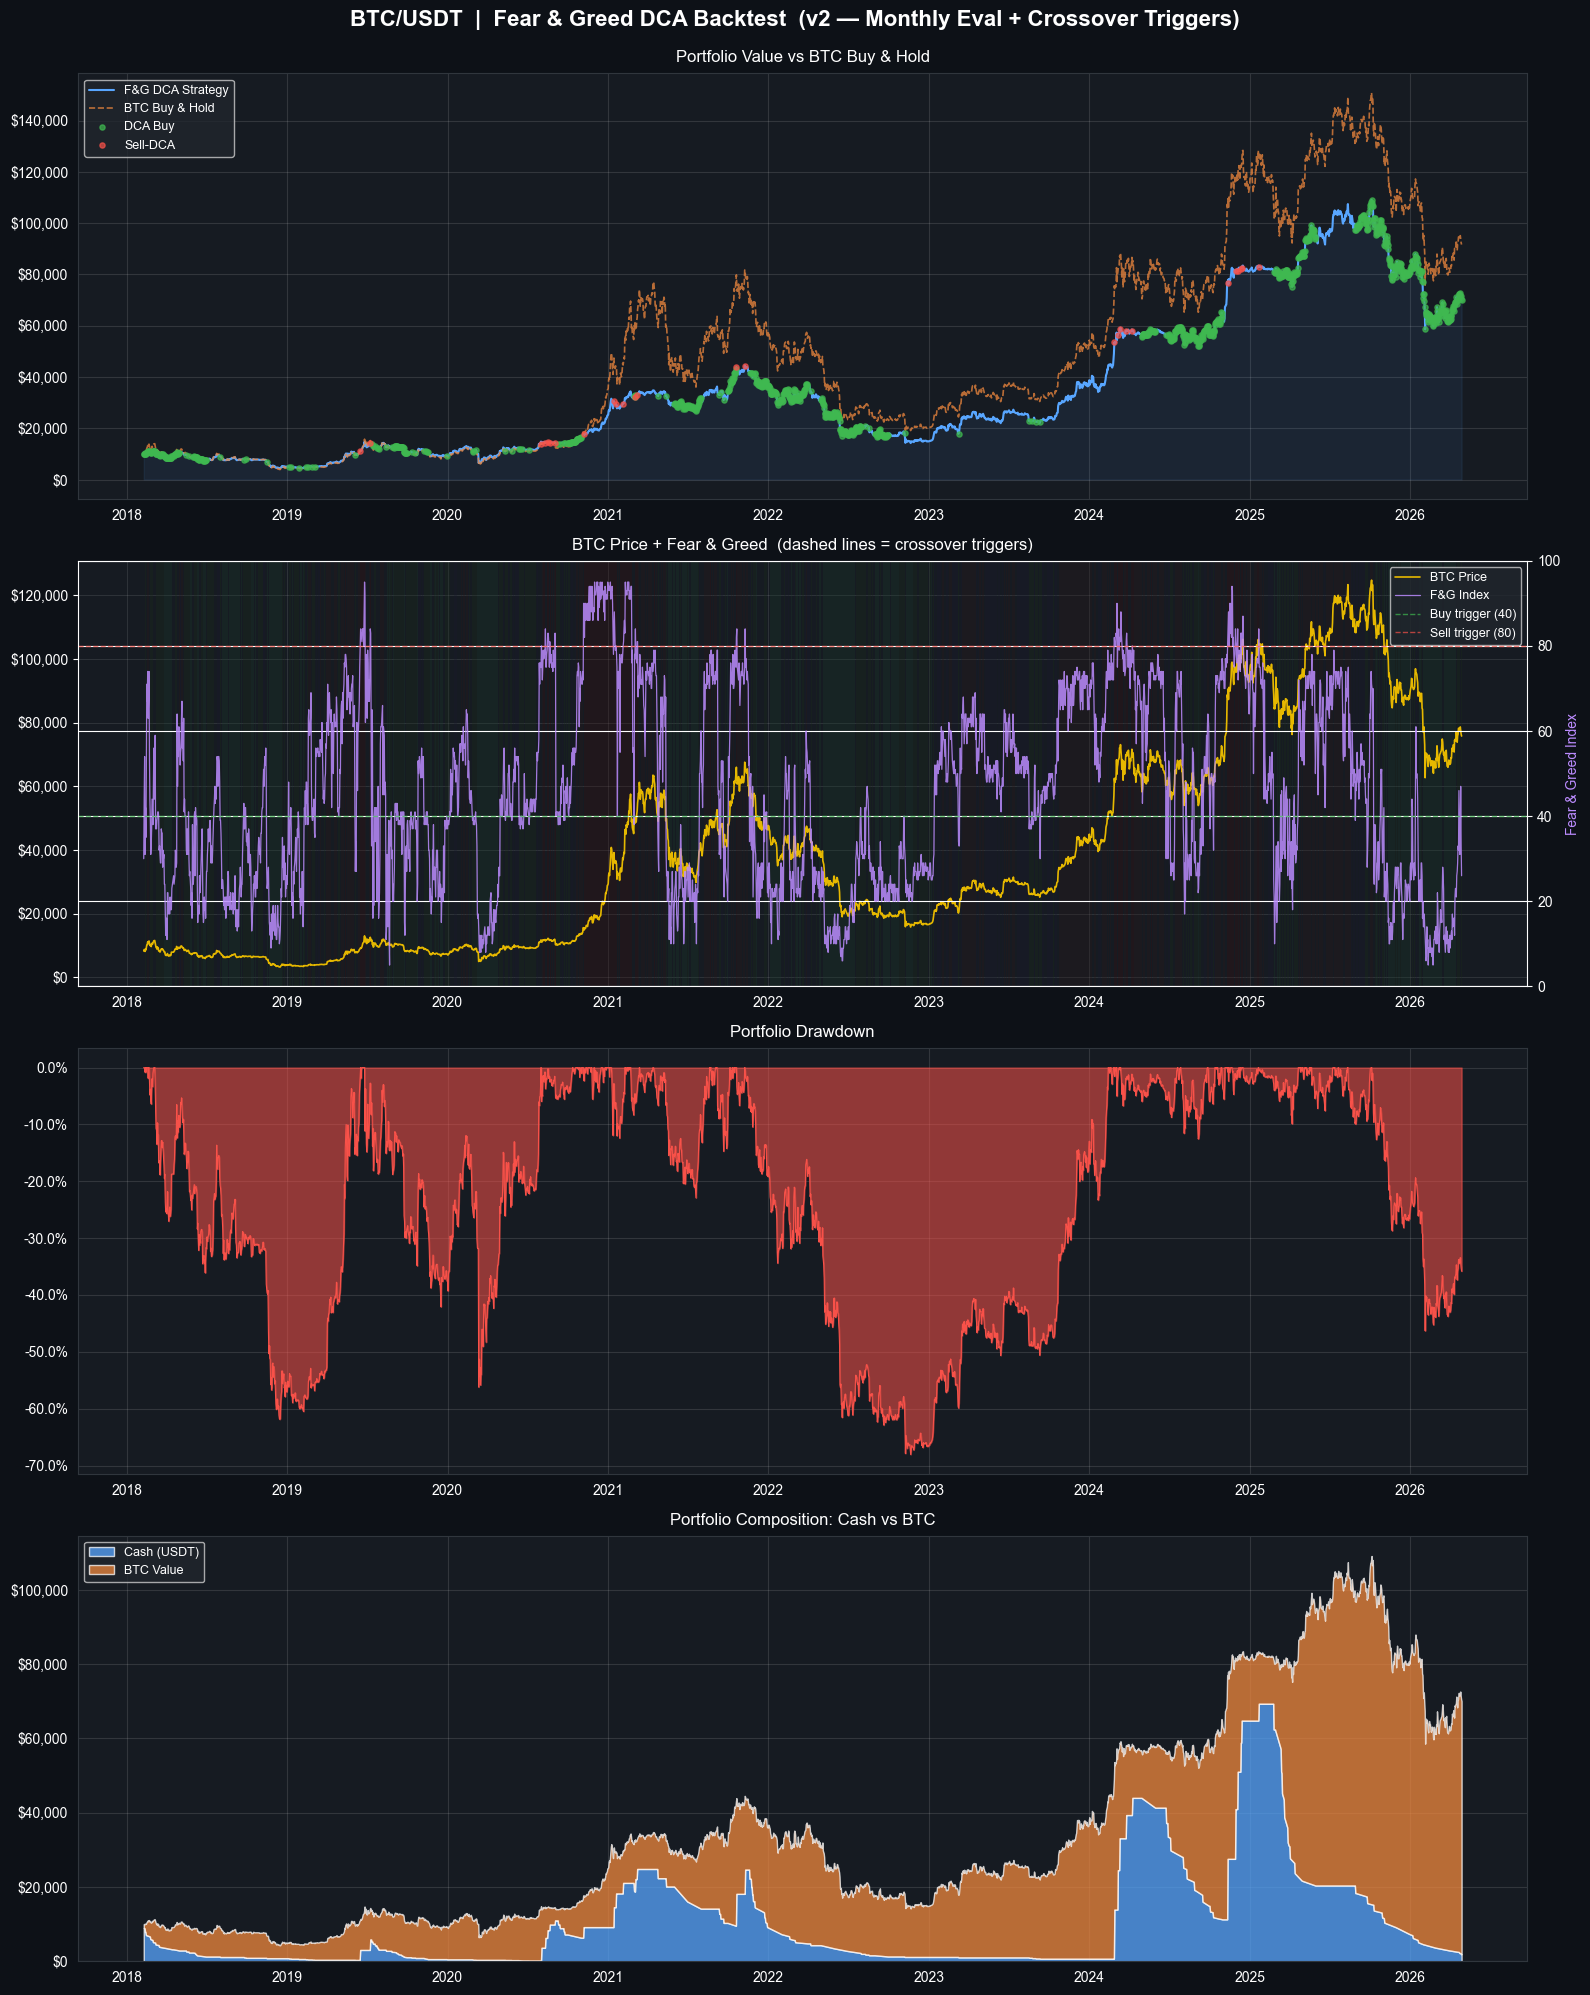

In [23]:
bh_curve = PARAMS['initial_capital'] * results['price'] / results['price'].iloc[0]
buys  = results[results['action'] == 'BUY']
sells = results[results['action'] == 'SELL']

fig, axes = plt.subplots(4, 1, figsize=(16, 20), facecolor='#0d1117')
fig.suptitle('BTC/USDT  |  Fear & Greed DCA Backtest  (v2 — Monthly Eval + Crossover Triggers)',
             fontsize=16, color='white', fontweight='bold', y=0.995)

# ── Panel 1: Portfolio value ────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#161b22')
ax.plot(results['date'], results['portfolio_value'],
        color='#58a6ff', lw=1.5, label='F&G DCA Strategy')
ax.plot(results['date'], bh_curve,
        color='#f0883e', lw=1.2, ls='--', alpha=0.75, label='BTC Buy & Hold')
ax.fill_between(results['date'], results['portfolio_value'],
                alpha=0.08, color='#58a6ff')
ax.scatter(buys['date'],  buys['portfolio_value'],
           s=14, color='#3fb950', zorder=5, alpha=0.7, label='DCA Buy')
ax.scatter(sells['date'], sells['portfolio_value'],
           s=14, color='#f85149', zorder=5, alpha=0.7, label='Sell-DCA')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Portfolio Value vs BTC Buy & Hold', color='white', pad=8)
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=9)
ax.grid(alpha=0.12)

# ── Panel 2: BTC price + F&G index with zone shading ───────────────────────
ax = axes[1]
ax.set_facecolor('#161b22')
ax2r = ax.twinx()

zone_colors = {
    'extreme_fear': '#1a3d2b',
    'fear':         '#1a2e1a',
    'neutral':      '#1a1a2e',
    'greed':        '#2e1a1a',
    'extreme_greed':'#3d1010',
}
bins   = [-1, 25, 45, 55, 75, 101]
labels = ['extreme_fear', 'fear', 'neutral', 'greed', 'extreme_greed']
results['fg_zone'] = pd.cut(results['fg_value'], bins=bins, labels=labels)
results['zone_run'] = (results['fg_zone'] != results['fg_zone'].shift()).cumsum()
for _, grp in results.groupby('zone_run', observed=True):
    zone = str(grp['fg_zone'].iloc[0])
    ax.axvspan(grp['date'].iloc[0], grp['date'].iloc[-1],
               alpha=0.28, color=zone_colors[zone], linewidth=0)

ax.plot(results['date'], results['price'], color='#e6b800', lw=1.2, label='BTC Price')
ax2r.plot(results['date'], results['fg_value'],
          color='#bc8cff', lw=0.9, alpha=0.85, label='F&G Index')
ax2r.axhline(40, color='#3fb950', ls='--', lw=1.0, alpha=0.7, label='Buy trigger (40)')
ax2r.axhline(80, color='#f85149', ls='--', lw=1.0, alpha=0.7, label='Sell trigger (80)')
ax2r.set_ylim(0, 100)
ax2r.set_ylabel('Fear & Greed Index', color='#bc8cff')
ax2r.tick_params(colors='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('BTC Price + Fear & Greed  (dashed lines = crossover triggers)',
             color='white', pad=8)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2r.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, facecolor='#21262d', labelcolor='white', fontsize=9)
ax.grid(alpha=0.10)

# ── Panel 3: Drawdown ───────────────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor('#161b22')
ax.fill_between(results['date'], drawdown_series * 100, 0,
                color='#f85149', alpha=0.55)
ax.plot(results['date'], drawdown_series * 100, color='#f85149', lw=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.set_title('Portfolio Drawdown', color='white', pad=8)
ax.grid(alpha=0.12)

# ── Panel 4: Portfolio composition ─────────────────────────────────────────
ax = axes[3]
ax.set_facecolor('#161b22')
ax.stackplot(results['date'],
             [results['cash'], results['btc_value']],
             labels=['Cash (USDT)', 'BTC Value'],
             colors=['#58a6ff', '#f0883e'], alpha=0.75)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Portfolio Composition: Cash vs BTC', color='white', pad=8)
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=9, loc='upper left')
ax.grid(alpha=0.12)

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    for spine in ax.spines.values():
        spine.set_color('#30363d')

plt.tight_layout()
plt.savefig('fg_dca_backtest.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

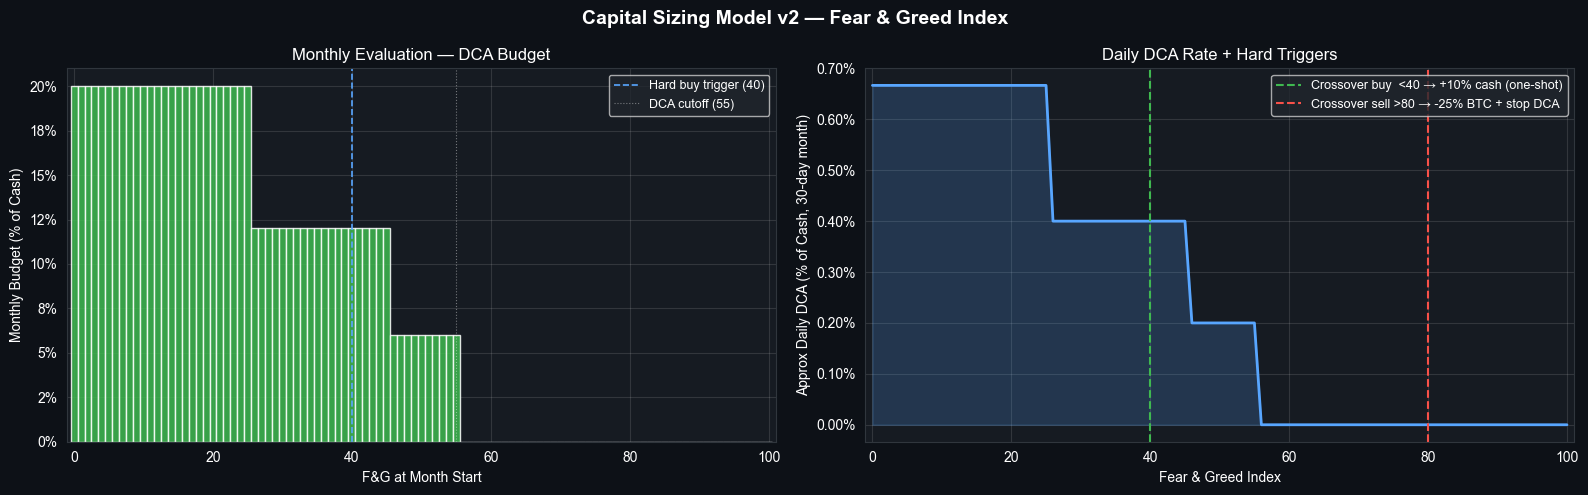

In [24]:
fg_range = list(range(0, 101))
monthly_pcts = [get_monthly_budget_pct(v, PARAMS['monthly_tiers']) * 100 for v in fg_range]
daily_pcts   = [p / 30 for p in monthly_pcts]  # approximate daily %

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0d1117')
fig.suptitle('Capital Sizing Model v2 — Fear & Greed Index', fontsize=14,
             color='white', fontweight='bold')

# Left: monthly budget by F&G level
ax = axes[0]
ax.set_facecolor('#161b22')
colors_m = ['#3fb950' if v > 0 else '#21262d' for v in monthly_pcts]
ax.bar(fg_range, monthly_pcts, color=colors_m, alpha=0.85, width=1.0)
ax.axvline(PARAMS['buy_trigger'], color='#58a6ff', ls='--', lw=1.2,
           label=f'Hard buy trigger ({PARAMS["buy_trigger"]})')
ax.axvline(55, color='white', ls=':', lw=0.8, alpha=0.4, label='DCA cutoff (55)')
ax.set_xlabel('F&G at Month Start', color='white')
ax.set_ylabel('Monthly Budget (% of Cash)', color='white')
ax.set_title('Monthly Evaluation — DCA Budget', color='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlim(-1, 101)
ax.tick_params(colors='white')
ax.grid(alpha=0.12)
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=9)

# Right: trigger levels annotated
ax = axes[1]
ax.set_facecolor('#161b22')
ax.plot(fg_range, daily_pcts, color='#58a6ff', lw=2)
ax.fill_between(fg_range, daily_pcts, alpha=0.2, color='#58a6ff')
ax.axvline(PARAMS['buy_trigger'], color='#3fb950', ls='--', lw=1.5,
           label=f'Crossover buy  <{PARAMS["buy_trigger"]} → +{PARAMS["buy_trigger_pct"]*100:.0f}% cash (one-shot)')
ax.axvline(PARAMS['sell_trigger'], color='#f85149', ls='--', lw=1.5,
           label=f'Crossover sell >{PARAMS["sell_trigger"]} → -{PARAMS["sell_trigger_pct"]*100:.0f}% BTC + stop DCA')
ax.set_xlabel('Fear & Greed Index', color='white')
ax.set_ylabel('Approx Daily DCA (% of Cash, 30-day month)', color='white')
ax.set_title('Daily DCA Rate + Hard Triggers', color='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}%'))
ax.set_xlim(-1, 101)
ax.tick_params(colors='white')
ax.grid(alpha=0.12)
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=9)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_color('#30363d')

plt.tight_layout()
plt.savefig('fg_capital_sizing.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

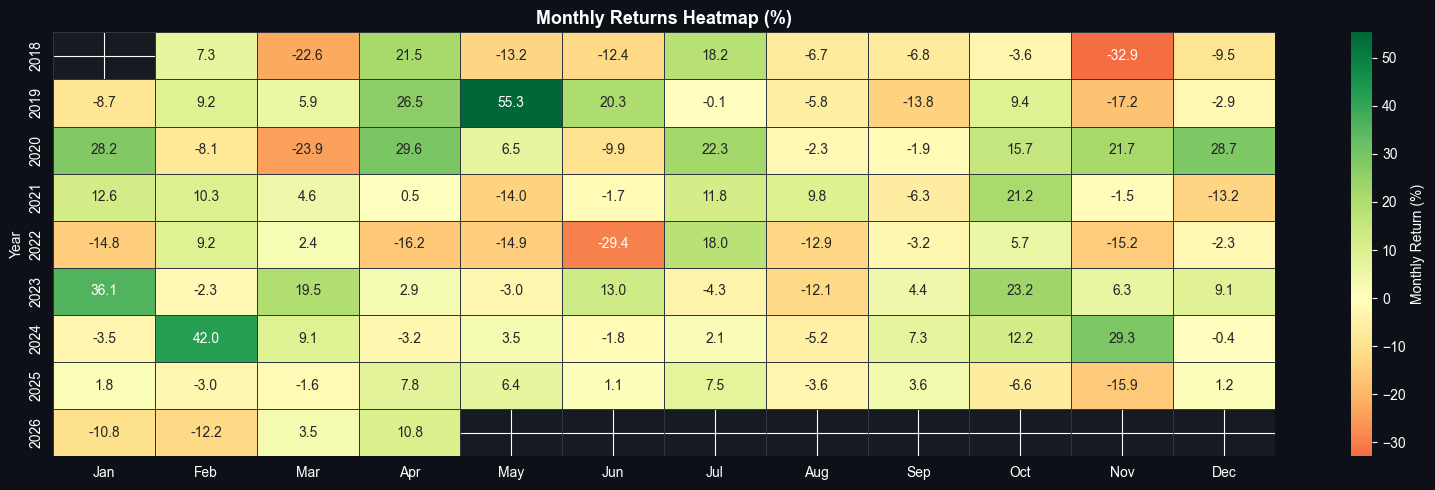

In [25]:
results['year']  = results['date'].dt.year
results['month'] = results['date'].dt.month

monthly = results.groupby(['year', 'month']).agg(
    pv_start=('portfolio_value', 'first'),
    pv_end  =('portfolio_value', 'last')
).reset_index()
monthly['ret'] = (monthly['pv_end'] - monthly['pv_start']) / monthly['pv_start'] * 100

pivot = monthly.pivot(index='year', columns='month', values='ret')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.columns = [month_labels[m - 1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(16, 5), facecolor='#0d1117')
ax.set_facecolor('#161b22')
sns.heatmap(
    pivot, annot=True, fmt='.1f', center=0,
    cmap='RdYlGn', ax=ax,
    linewidths=0.5, linecolor='#30363d',
    cbar_kws={'label': 'Monthly Return (%)'}
)
ax.set_title('Monthly Returns Heatmap (%)', color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.set_xlabel('', color='white')
ax.set_ylabel('Year', color='white')
plt.tight_layout()
plt.savefig('fg_monthly_returns.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [26]:
# ── Final summary print ─────────────────────────────────────────────────────
print('=' * 50)
print('   FEAR & GREED DCA v2 — BACKTEST SUMMARY')
print('=' * 50)
for _, row in metrics_df.iterrows():
    print(f'  {row["Metric"]:<28}  {row["Value"]}')
print('=' * 50)
print(f'  Period: {results.date.min().date()} → {results.date.max().date()}')
print(f'  Total deployed USDT: ${results[results["action"]=="BUY"]["trade_usdt"].sum():,.2f}')
print(f'  Total sold USDT:     ${results[results["action"]=="SELL"]["trade_usdt"].sum():,.2f}')
print(f'  Remaining BTC:       {results["btc_held"].iloc[-1]:.8f} BTC')
print(f'  Remaining Cash:      ${results["cash"].iloc[-1]:,.2f}')
print('=' * 50)

   FEAR & GREED DCA v2 — BACKTEST SUMMARY
  Initial Capital               $10,000
  Final Portfolio Value         $70,045.74
  Total Return                  600.46%
  CAGR                          26.75%
  Sharpe Ratio                  0.6574
  Sortino Ratio                 0.8524
  Max Drawdown                  -68.05%
  Max DD Duration (days)        827
  Buy Signals                   1046
  Sell Signals                  26
  BTC Buy & Hold Return         816.77%
  Period: 2018-02-08 → 2026-04-29
  Total deployed USDT: $161,732.79
  Total sold USDT:     $153,795.45
  Remaining BTC:       0.89918657 BTC
  Remaining Cash:      $1,908.86
